 ## Random Forest

Modelo de clasificación binaria para predecir si la MTA publicará una alerta oficial
en los próximos 30 minutos para una línea concreta.



## 0) Setup

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')
plt.rcParams['figure.figsize'] = (14, 5)

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet


TARGET_COL = "alert_in_next_30m"
RANDOM_STATE = 42

# Columnas categóricas que necesitan encoding para sklearn
CAT_COLS = ['route_id', 'direction', 'tipo_referente']

print("✓ Setup completado")

✓ Setup completado


## 1) Carga de datos desde MinIO

In [24]:
access_key = os.getenv("MINIO_ACCESS_KEY")
secret_key = os.getenv("MINIO_SECRET_KEY")
if not access_key or not secret_key:
    raise ValueError("MINIO_ACCESS_KEY y MINIO_SECRET_KEY deben estar definidas")

print("Cargando datasets desde MinIO...")

MINIO_PATH_ENE = "grupo5/final/year=2025/month=01/dataset_final.parquet"
MINIO_PATH_FEB = "grupo5/final/year=2025/month=02/dataset_final.parquet"

df_enero  = download_df_parquet(access_key, secret_key, MINIO_PATH_ENE)
df_febrero = download_df_parquet(access_key, secret_key, MINIO_PATH_FEB)

df = pd.concat([df_enero, df_febrero], ignore_index=True)

print(f"\n✓ Enero:   {df_enero.shape[0]:,} filas")
print(f"✓ Febrero: {df_febrero.shape[0]:,} filas")
print(f"✓ Total:   {df.shape[0]:,} filas × {df.shape[1]} columnas")

Cargando datasets desde MinIO...

✓ Enero:   6,401,887 filas
✓ Febrero: 5,683,208 filas
✓ Total:   12,085,095 filas × 47 columnas


## 2)

Esperamos un desbalance muy marcado: la mayoría de observaciones son momentos normales.

Distribución de 'alert_in_next_30m':
  Normal     (0): 10,661,453  (88.22%)
  Pre-alerta (1): 1,423,642  (11.78%)
  Ratio desbalance: 7:1

→ Usaremos class_weight='balanced' para compensar el desbalance


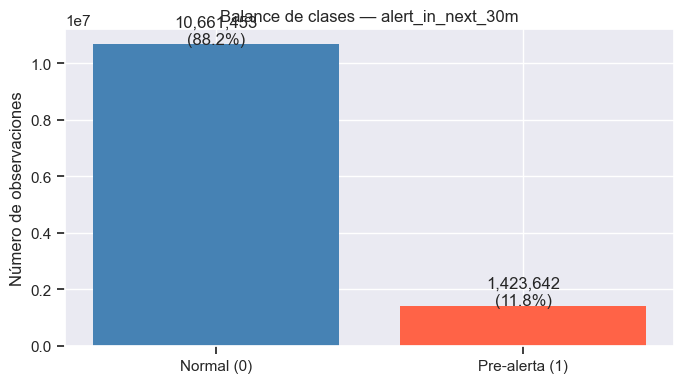

In [26]:
# Distribución del target
vc = df[TARGET_COL].value_counts()
ratio = vc[0] / vc[1]

print(f"Distribución de '{TARGET_COL}':")
print(f"  Normal     (0): {vc[0]:>9,}  ({vc[0]/len(df)*100:.2f}%)")
print(f"  Pre-alerta (1): {vc[1]:>9,}  ({vc[1]/len(df)*100:.2f}%)")
print(f"  Ratio desbalance: {ratio:.0f}:1")
print(f"\n→ Usaremos class_weight='balanced' para compensar el desbalance")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Normal (0)", "Pre-alerta (1)"], vc.values, color=["steelblue", "tomato"])
ax.set_title(f"Balance de clases — {TARGET_COL}")
ax.set_ylabel("Número de observaciones")
for i, v in enumerate(vc.values):
    ax.text(i, v + len(df)*0.001, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center")
plt.tight_layout()
plt.show()

## 3) Selección de features y encoding

Usamos las mismas 21 variables que `tecnica_XGBoost.ipynb` para que los resultados
sean comparables directamente.

A diferencia de XGBoost, **Random Forest de sklearn necesita que las variables
categóricas sean numéricas**. Aplicamos `LabelEncoder` a `route_id`, `direction`
y `tipo_referente`.

In [28]:
FEATURE_COLS = [
    'delay_seconds', 'lagged_delay_1', 'lagged_delay_2',
    'route_rolling_delay', 'actual_headway_seconds',
    'is_unscheduled', 'num_updates', 'scheduled_time_to_end',
    'stops_to_end', 'route_id', 'direction',
    'hour_sin', 'hour_cos', 'dow', 'is_weekend',
    'n_eventos_afectando', 'tipo_referente',
    'afecta_previo', 'afecta_durante', 'afecta_despues',
    'temp_extreme',
]

# Verificar que todas las features existen en el dataset
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"⚠️  Columnas no encontradas: {missing}")
    FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
    print(f"   Continuando con {len(FEATURE_COLS)} features")
else:
    print(f"✓ Las {len(FEATURE_COLS)} features están disponibles")

# Ordenar por tiempo (crítico para split temporal)
df['merge_time'] = pd.to_datetime(df['merge_time'])
df = df.sort_values('merge_time').reset_index(drop=True)

# Eliminar filas sin target
df = df.dropna(subset=[TARGET_COL]).copy()
df[TARGET_COL] = df[TARGET_COL].astype(int)

# LabelEncoder para categóricas
encoders = {}
for col in CAT_COLS:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str).fillna('UNKNOWN'))
        encoders[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} categorías")

# Rellenar NaN en features numéricas con la mediana
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median(numeric_only=True))

print(f"\nDataset listo: {len(df):,} filas")

✓ Las 21 features están disponibles
  Encoded 'route_id': 27 categorías
  Encoded 'direction': 2 categorías
  Encoded 'tipo_referente': 6 categorías

Dataset listo: 12,085,095 filas


#### Aquí lo que se hace es, basada la idea en este artículo : https://pub.towardsai.net/can-you-predict-a-subway-delay-before-transit-officials-announce-it-ec16cab64149
Para los alert_in_next_30m = 0 , solo cogen los momentos donde el metro está genuinamente tranquilo (alerta a más de 1 hora o nunca) . Porque si hay una alerta a 45 mins, esa fila tiene alert_in_next_30m = 0, pero el metro en ese momento ya está empezando a fallar pero el target dice que 'normal'. Eso confunde al modelo

In [30]:
mask_positivos = df[TARGET_COL] == 1
mask_negativos_limpios = (
    df['seconds_to_next_alert'].isna() |      
    (df['seconds_to_next_alert'] > 3600)       
)

df = df[mask_positivos | mask_negativos_limpios].copy()
df = df.reset_index(drop=True)

print(f"Dataset tras filtrar negativos ambiguos: {len(df):,} filas")
print(f"  Positivos: {df[TARGET_COL].sum():,} ({df[TARGET_COL].mean()*100:.1f}%)")
print(f"  Negativos: {(df[TARGET_COL]==0).sum():,} ({(df[TARGET_COL]==0).mean()*100:.1f}%)")

Dataset tras filtrar negativos ambiguos: 11,204,923 filas
  Positivos: 1,423,642 (12.7%)
  Negativos: 9,781,281 (87.3%)


## 4) Split  70 / 15 / 15



In [31]:
n = len(df)
i_train = int(n * 0.70)
i_val   = int(n * 0.85)

df_train = df.iloc[:i_train]
df_val   = df.iloc[i_train:i_val]
df_test  = df.iloc[i_val:]

X_train, y_train = df_train[FEATURE_COLS], df_train[TARGET_COL]
X_val,   y_val   = df_val[FEATURE_COLS],   df_val[TARGET_COL]
X_test,  y_test  = df_test[FEATURE_COLS],  df_test[TARGET_COL]

for name, subset, y in [("Train", df_train, y_train),
                         ("Val",   df_val,   y_val),
                         ("Test",  df_test,  y_test)]:
    pos = y.sum()
    print(f"{name:5s}: {len(subset):>9,} obs | pre-alerta: {pos:>6,} ({pos/len(subset)*100:.2f}%) "
          f"| {subset['merge_time'].min().date()} → {subset['merge_time'].max().date()}")

Train: 7,843,446 obs | pre-alerta: 993,495 (12.67%) | 2025-01-01 → 2025-02-11
Val  : 1,680,738 obs | pre-alerta: 238,794 (14.21%) | 2025-02-11 → 2025-02-20
Test : 1,680,739 obs | pre-alerta: 191,353 (11.39%) | 2025-02-20 → 2025-02-28


## 5) Entrenamiento del Random Forest

Parámetros clave:
- class_weight='balanced` — compensa el desbalance 99:1 automáticamente
- max_depth=15 — limitar la profundidad reduce el tiempo de entrenamiento y el sobreajuste
- min_samples_leaf=50 — cada hoja necesita al menos 50 observaciones (evita sobreajuste)
- n_jobs=-1 — usa todos los núcleos disponibles en paralelo

In [34]:
import time

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=50,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print("Entrenando Random Forest...")
t0 = time.time()
rf.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\n✓ Entrenamiento completado en {elapsed/60:.1f} minutos")

Entrenando Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed: 16.9min



✓ Entrenamiento completado en 18.9 minutos


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 18.9min finished


## 6) Evaluación en validación y test

Las métricas importantes son:
- **Recall**: de todas las alertas reales, ¿cuántas detectamos? (no queremos perdernos alertas)
- **Precision**: de lo que predecimos como alerta, ¿cuántas eran reales? (no queremos alarmas falsas)
- **F1**: media armónica de precision y recall
- **AUC-ROC**: capacidad discriminativa general del modelo

In [36]:
def evaluar_modelo(nombre, model, X, y):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        "Modelo":    nombre,
        "Accuracy":  round(accuracy_score(y, y_pred), 4),
        "Precision": round(precision_score(y, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y, y_pred, zero_division=0), 4),
        "AUC-ROC":   round(roc_auc_score(y, y_proba), 4),
    }

res_val  = evaluar_modelo("RF — Validación", rf, X_val, y_val)
res_test = evaluar_modelo("RF — Test",       rf, X_test, y_test)

df_resultados = pd.DataFrame([res_val, res_test]).set_index("Modelo")
print("=== Resultados Random Forest ===")
display(df_resultados)

print("\n=== Reporte detallado (Test) ===")
y_pred_test = rf.predict(X_test)
print(classification_report(y_test, y_pred_test, target_names=["Normal", "Pre-alerta"]))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.1s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    7.3s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    8.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.1s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    7.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    7.9s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.1s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    7.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    7.9s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.1s
[Parallel(n_jobs=12)]: Do

=== Resultados Random Forest ===


,Accuracy,Precision,Recall,F1,AUC-ROC
Modelo,,,,,
RF — Validación,0.6077,0.2488,0.8721,0.3871,0.7760
RF — Test,0.5708,0.1884,0.8373,0.3076,0.7353



=== Reporte detallado (Test) ===


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    7.2s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    8.0s finished


              precision    recall  f1-score   support

      Normal       0.96      0.54      0.69   1489386
  Pre-alerta       0.19      0.84      0.31    191353

    accuracy                           0.57   1680739
   macro avg       0.58      0.69      0.50   1680739
weighted avg       0.87      0.57      0.65   1680739



## 7) Matriz de confusión

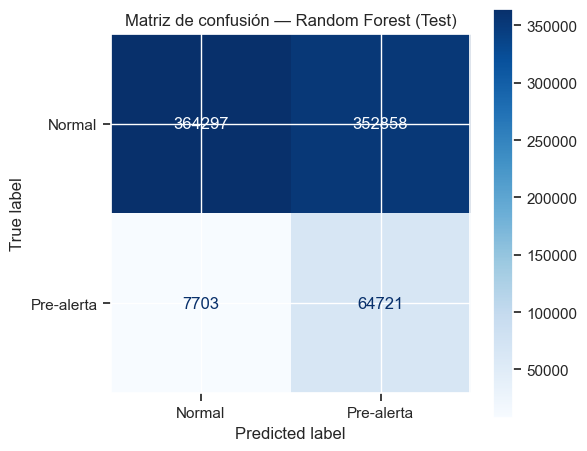

Verdaderos negativos (Normal bien clasificado):    364,297
Falsos positivos (Normal clasificado como alerta): 352,858
Falsos negativos (Alerta no detectada):            7,703  ← los más costosos
Verdaderos positivos (Alerta detectada):           64,721


In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=["Normal", "Pre-alerta"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Matriz de confusión — Random Forest (Test)")
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print(f"Verdaderos negativos (Normal bien clasificado):    {tn:,}")
print(f"Falsos positivos (Normal clasificado como alerta): {fp:,}")
print(f"Falsos negativos (Alerta no detectada):            {fn:,}  ← los más costosos")
print(f"Verdaderos positivos (Alerta detectada):           {tp:,}")